# Laboratory Work 4: Clustering & Dimensionality Reduction

**Course:** Machine Learning 2 (ML2)  
**Topic:** Applying and comparing Clustering algorithms (K-Means, Agglomerative, DBSCAN, GMM) combined with Dimensionality Reduction (PCA, t-SNE) with MLflow tracking.

### Objectives:
1. **Dataset & Feature Engineering:** Analyze Obesity dataset, engineer domain features (BMI, Age_BMI, Water_per_Meal), and scale with StandardScaler.
2. **Dimension Reduction:** Use PCA (scree plot) and t-SNE (2D manifold) to visualize and explain data variance.
3. **Clustering Diagnostics:** Find suitable parameters using Elbow/Silhouette (K-Means), Dendrogram (Hierarchical), and K-distance knee plot (DBSCAN).
4. **Clustering Benchmark:** Compare K-Means, Agglomerative, DBSCAN, and GMM on Original (25D) vs PCA (6D) spaces.
5. **Evaluation:** Log internal (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external (ARI, NMI) metrics to MLflow.
6. **Conclusion:** Analyze how dimension reduction affects cluster separation and stability.


In [1]:
import os
import sys
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure
)

import mlflow
import mlflow.sklearn

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
os.makedirs("plots", exist_ok=True)

TRACKING_URI = "http://localhost:5000/"
EXPERIMENT_NAME = "Lab4_Clustering_Dimension_Reduction"

try:
    mlflow.set_tracking_uri(TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print(f"[MLflow] Connected to tracking server at: {TRACKING_URI}")
    print(f"[MLflow] Active Experiment: '{EXPERIMENT_NAME}'")
except Exception as e:
    print(f"[MLflow] Remote server unreachable ({e}). Falling back to local './mlruns' directory.")
    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment(EXPERIMENT_NAME)


[MLflow] Connected to tracking server at: http://localhost:5000/
[MLflow] Active Experiment: 'Lab4_Clustering_Dimension_Reduction'


## 1. Dataset Loading, Exploration & Feature Engineering

We use the **Estimation of Obesity Levels Based On Eating Habits and Physical Condition** dataset:
- **Source:** UCI Machine Learning Repository / OpenML (Dataset ID: `45969`, published 2019).
- **Scale:** 2,111 instances, 16 input features + 1 target (`NObeyesdad`).
- **Target:** 7 categories (`Insufficient_Weight`, `Normal_Weight`, `Overweight_Level_I`, `Overweight_Level_II`, `Obesity_Type_I`, `Obesity_Type_II`, `Obesity_Type_III`).
- **Feature Engineering:**
  - $\text{BMI} = \frac{\text{Weight}}{\text{Height}^2}$: Body Mass Index.
  - $\text{Age\_BMI} = \text{Age} \times \text{BMI}$: Interaction term.
  - $\text{Water\_per\_Meal} = \frac{\text{CH2O}}{\text{NCP} + 0.1}$: Daily water intake per main meal.


Fetching Obesity Levels dataset from OpenML (did=45969)...
Dataset Shape: 2111 rows, 17 columns
Missing Values: 0
Target Variable: 'NObeyesdad' with 7 clinical categories:
  Class 0: Insufficient_Weight        (272 samples, 12.9%)
  Class 1: Normal_Weight              (287 samples, 13.6%)
  Class 2: Obesity_Type_I             (351 samples, 16.6%)
  Class 3: Obesity_Type_II            (297 samples, 14.1%)
  Class 4: Obesity_Type_III           (324 samples, 15.3%)
  Class 5: Overweight_Level_I         (290 samples, 13.7%)
  Class 6: Overweight_Level_II        (290 samples, 13.7%)
Total features after One-Hot Encoding: 26
Feature matrix scaled using StandardScaler. Shape: (2111, 26)


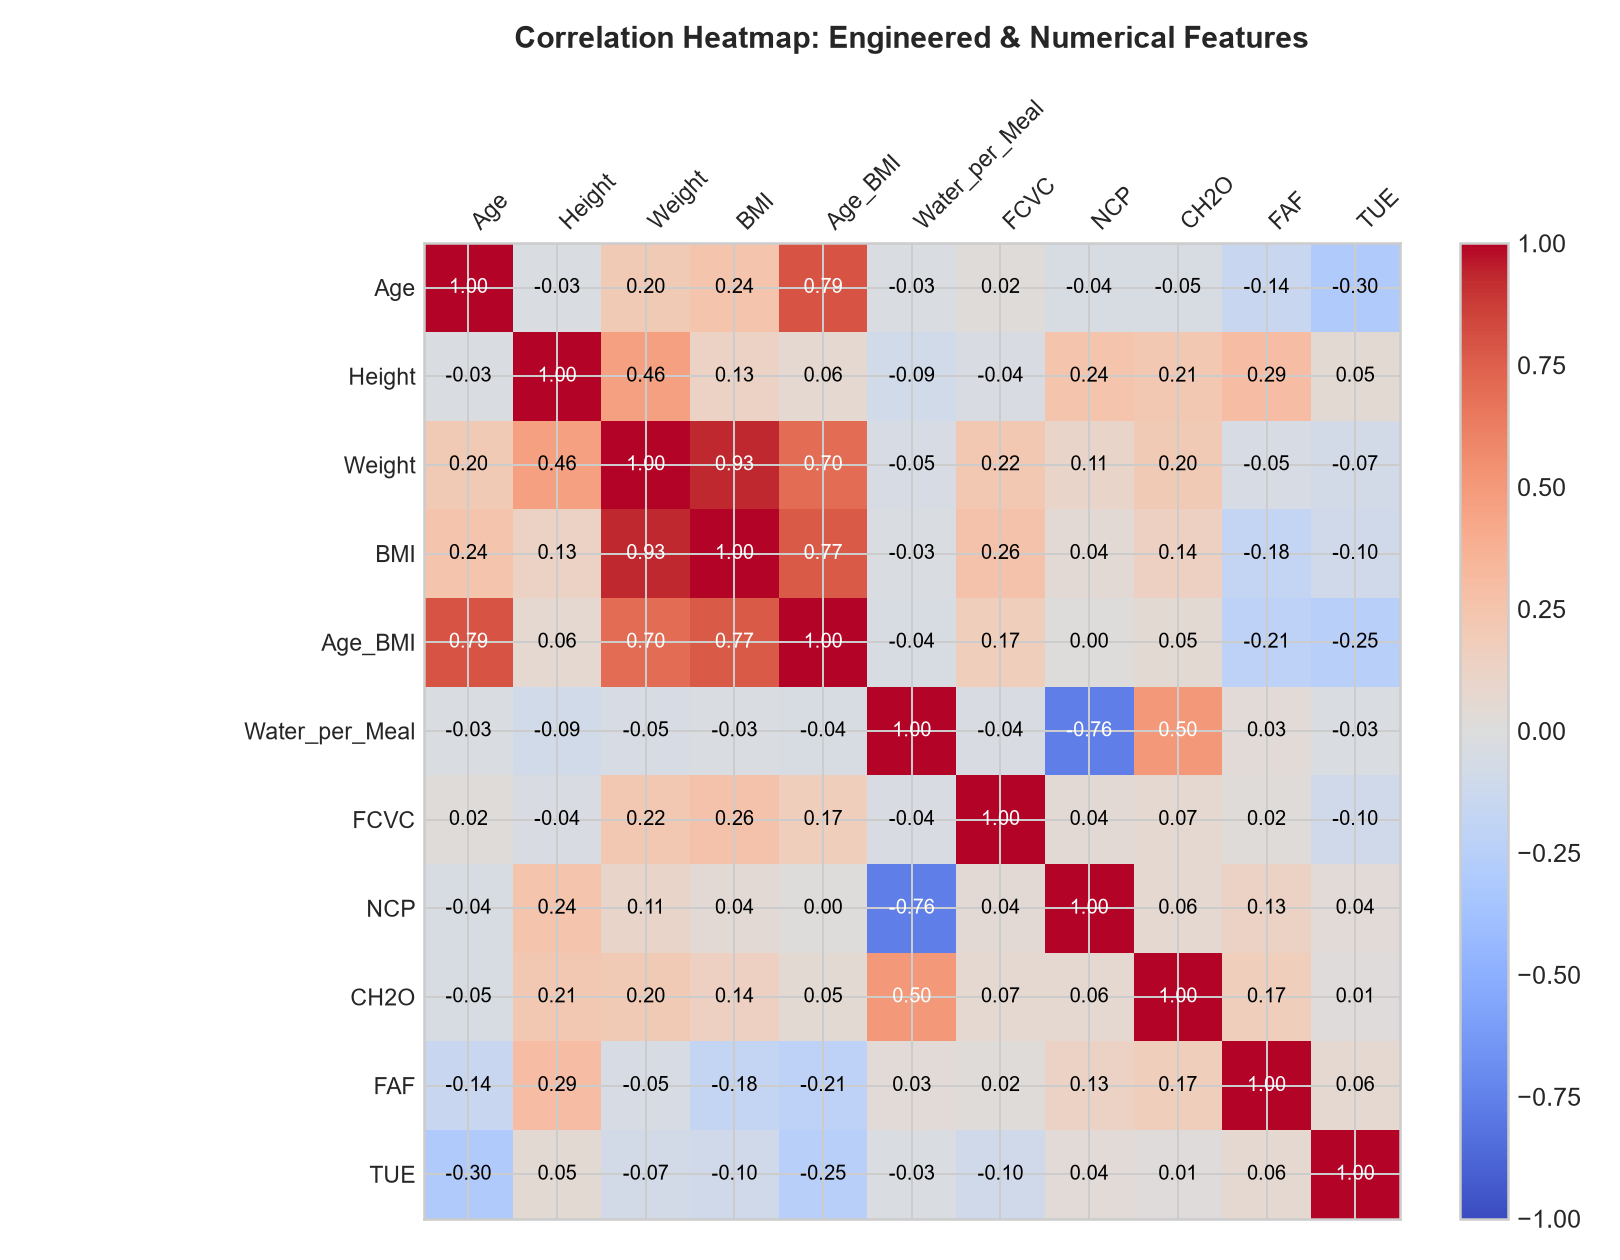

In [2]:
print("Fetching Obesity Levels dataset from OpenML (did=45969)...")
data = fetch_openml(data_id=45969, as_frame=True)
df = data.frame.copy()

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing Values: {df.isnull().sum().sum()}")

target_col = "NObeyesdad"
y_raw = df[target_col]
label_encoder = LabelEncoder()
y_true = label_encoder.fit_transform(y_raw)
class_names = list(label_encoder.classes_)

# Domain Feature Engineering
df["BMI"] = df["Weight"] / (df["Height"] ** 2)
df["Age_BMI"] = df["Age"] * df["BMI"]
df["Water_per_Meal"] = df["CH2O"] / (df["NCP"] + 0.1)

# Categorical One-Hot Encoding
X_raw = df.drop(columns=[target_col])
X_encoded = pd.get_dummies(X_raw, drop_first=True, dtype=float)
feature_names = list(X_encoded.columns)
print(f"Total features after One-Hot Encoding: {len(feature_names)}")

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
print(f"Feature matrix scaled using StandardScaler. Shape: {X_scaled.shape}")

# Correlation Heatmap
corr_features = ["Age", "Height", "Weight", "BMI", "Age_BMI", "Water_per_Meal", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
available_corr_cols = [c for c in corr_features if c in df.columns]
corr_matrix = df[available_corr_cols].corr()

fig_corr, ax_corr = plt.subplots(figsize=(9, 7))
cax = ax_corr.matshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
fig_corr.colorbar(cax, ax=ax_corr, fraction=0.046, pad=0.04)

ax_corr.set_xticks(range(len(available_corr_cols)))
ax_corr.set_yticks(range(len(available_corr_cols)))
ax_corr.set_xticklabels(available_corr_cols, rotation=45, ha="left", fontsize=9)
ax_corr.set_yticklabels(available_corr_cols, fontsize=9)

for i in range(len(available_corr_cols)):
    for j in range(len(available_corr_cols)):
        val = corr_matrix.iloc[i, j]
        ax_corr.text(j, i, f"{val:.2f}", ha="center", va="center",
                     color="white" if abs(val) > 0.5 else "black", fontsize=8)

ax_corr.set_title("Correlation Heatmap: Engineered & Numerical Features", fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
corr_plot_path = "plots/eda_correlation_heatmap.png"
fig_corr.savefig(corr_plot_path, dpi=180)
plt.show()


## 2. Dimension Reduction (PCA & t-SNE) & 2D Visualizations

We apply two dimensionality reduction algorithms:
1. **PCA (Principal Component Analysis):** Unsupervised orthogonal linear projection maximizing variance.
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Non-linear manifold learning for 2D visualization.


Top 2 Principal Components explain: 24.98% of total variance.
Components needed for 80% variance: 13
Components needed for 90% variance: 16


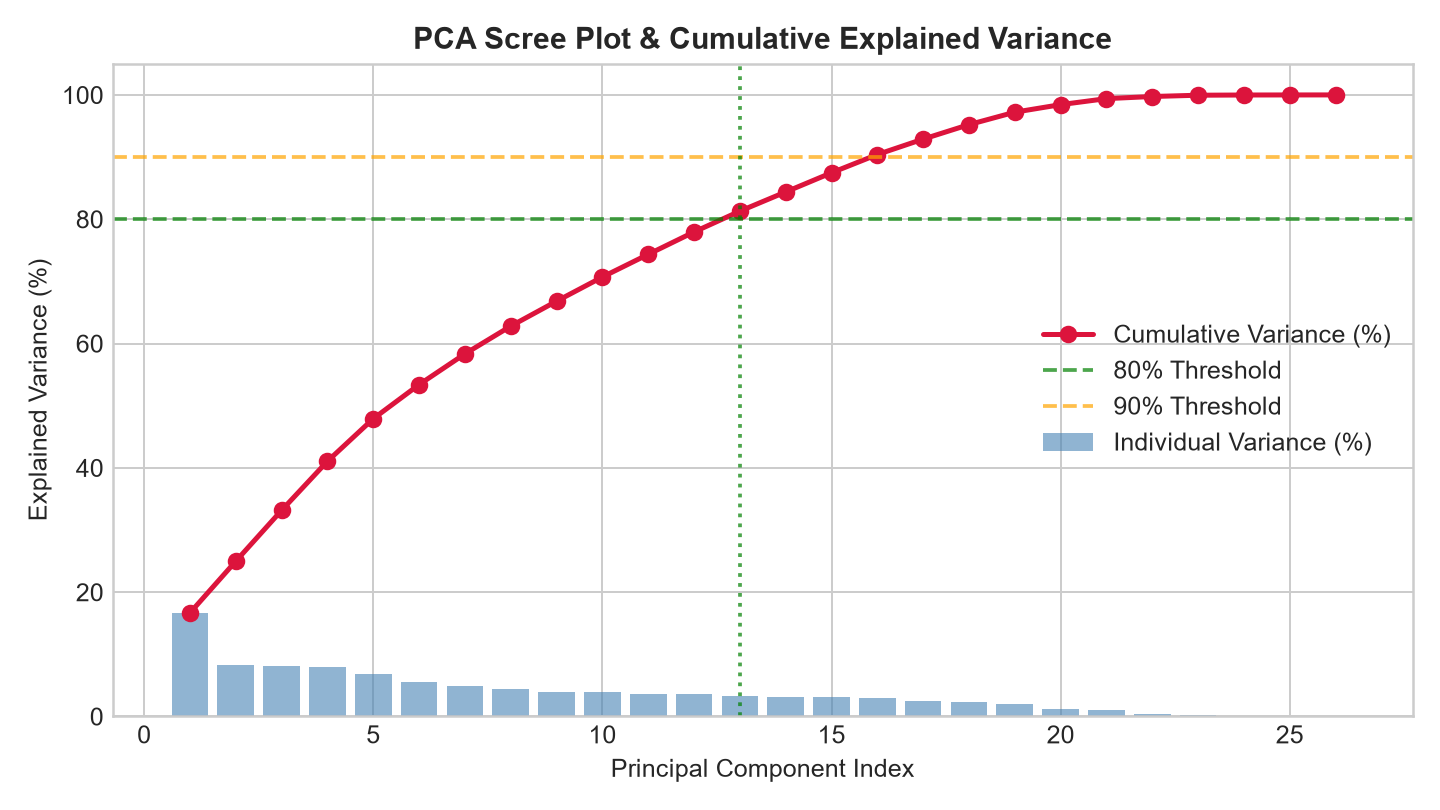

Data reduced from 26D to 6D using PCA (Explains 53.39% variance).
Top Features driving PC1: Weight, BMI, Age_BMI, CAEC_Sometimes
Top Features driving PC2: Height, Gender_Male, FAF, NCP
Computing t-SNE 2D projection...


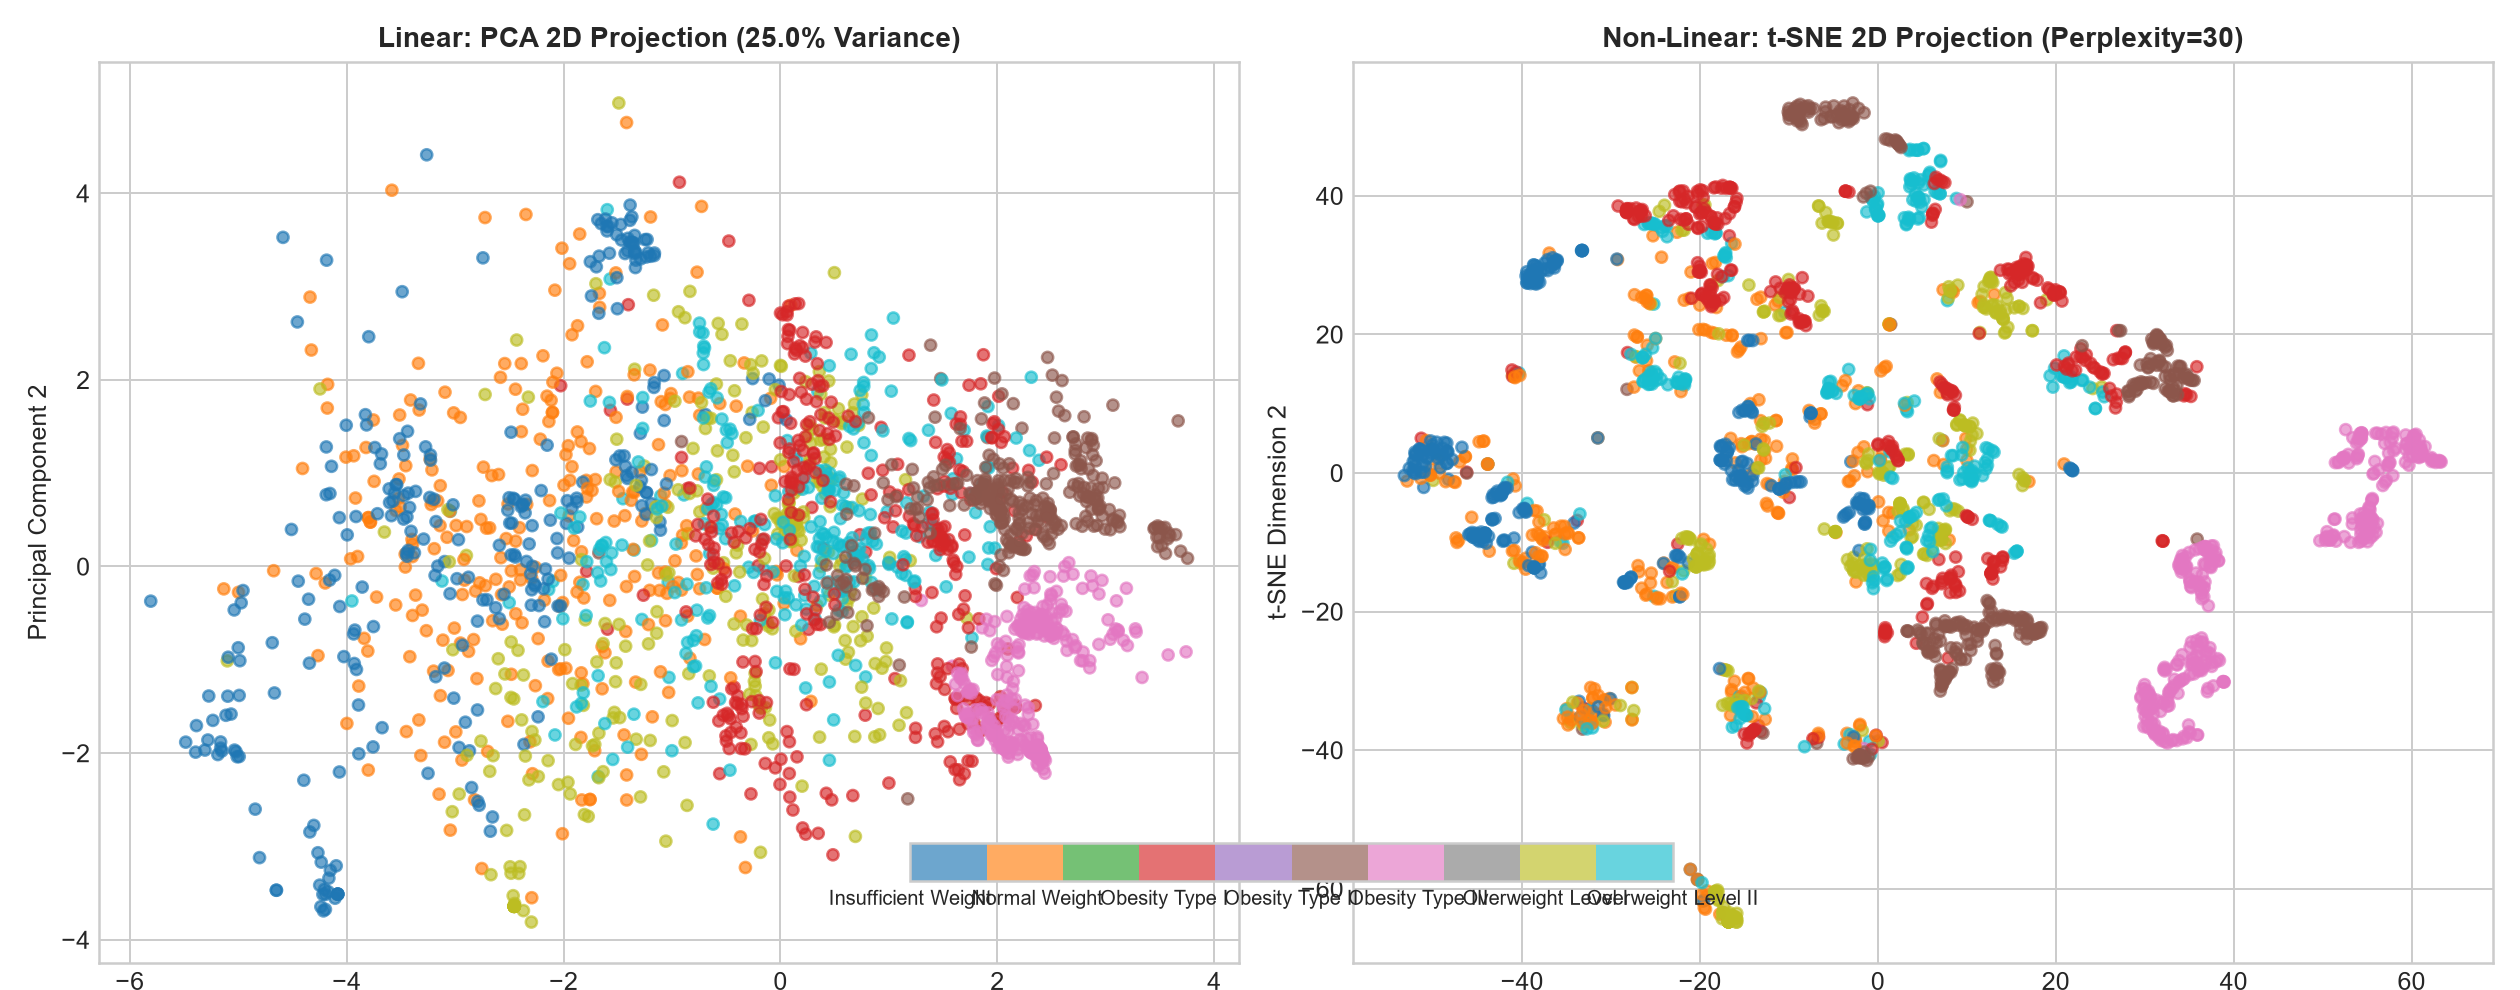

In [3]:
# PCA Full Decomposition
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

n_comp_80 = int(np.argmax(cum_var >= 0.80) + 1)
n_comp_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"Top 2 Principal Components explain: {cum_var[1]*100:.2f}% of total variance.")
print(f"Components needed for 80% variance: {n_comp_80}")
print(f"Components needed for 90% variance: {n_comp_90}")

# Scree Plot & Cumulative Variance
fig_scree, ax_scree = plt.subplots(figsize=(8, 4.5))
ax_scree.bar(range(1, len(exp_var) + 1), exp_var * 100, alpha=0.6, color="steelblue", label="Individual Variance (%)")
ax_scree.plot(range(1, len(cum_var) + 1), cum_var * 100, color="crimson", marker="o", linewidth=2, label="Cumulative Variance (%)")
ax_scree.axhline(80, color="green", linestyle="--", alpha=0.7, label="80% Threshold")
ax_scree.axhline(90, color="orange", linestyle="--", alpha=0.7, label="90% Threshold")
ax_scree.axvline(n_comp_80, color="green", linestyle=":", alpha=0.7)
ax_scree.set_xlabel("Principal Component Index", fontsize=10)
ax_scree.set_ylabel("Explained Variance (%)", fontsize=10)
ax_scree.set_title("PCA Scree Plot & Cumulative Explained Variance", fontsize=12, fontweight="bold")
ax_scree.legend(loc="center right")
plt.tight_layout()
fig_scree.savefig("plots/pca_scree_variance.png", dpi=180)
plt.show()

# Reduce to 6 Principal Components (~54% variance)
N_PCA_COMPONENTS = 6
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Data reduced from {X_scaled.shape[1]}D to {X_pca.shape[1]}D using PCA (Explains {np.sum(pca.explained_variance_ratio_)*100:.2f}% variance).")

# Component Loadings
loadings_df = pd.DataFrame(pca.components_[:2, :], columns=feature_names, index=["PC1", "PC2"]).T
top_pc1 = loadings_df["PC1"].abs().nlargest(4).index.tolist()
top_pc2 = loadings_df["PC2"].abs().nlargest(4).index.tolist()
print(f"Top Features driving PC1: {', '.join(top_pc1)}")
print(f"Top Features driving PC2: {', '.join(top_pc2)}")

# t-SNE 2D Manifold Projection
print("Computing t-SNE 2D projection...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# 2D PCA vs 2D t-SNE Visualizations
fig_dr, axes_dr = plt.subplots(1, 2, figsize=(14, 5.5))

scatter1 = axes_dr[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="tab10", alpha=0.65, s=20)
axes_dr[0].set_title(f"Linear: PCA 2D Projection ({cum_var[1]*100:.1f}% Variance)", fontsize=11, fontweight="bold")
axes_dr[0].set_xlabel("Principal Component 1")
axes_dr[0].set_ylabel("Principal Component 2")

scatter2 = axes_dr[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap="tab10", alpha=0.65, s=20)
axes_dr[1].set_title("Non-Linear: t-SNE 2D Projection (Perplexity=30)", fontsize=11, fontweight="bold")
axes_dr[1].set_xlabel("t-SNE Dimension 1")
axes_dr[1].set_ylabel("t-SNE Dimension 2")

cbar = fig_dr.colorbar(scatter2, ax=axes_dr, orientation="horizontal", fraction=0.05, pad=0.15)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels([c.replace("_", " ") for c in class_names], fontsize=8)
plt.tight_layout()
fig_dr.savefig("plots/dimension_reduction_projections.png", dpi=180)
plt.show()

# MLflow logging
with mlflow.start_run(run_name="EDA_and_Dimension_Reduction"):
    mlflow.set_tag("phase", "eda_and_dimension_reduction")
    mlflow.log_params({
        "dataset_rows": df.shape[0],
        "original_features": len(feature_names),
        "pca_components_selected": N_PCA_COMPONENTS,
        "n_classes": len(class_names)
    })
    mlflow.log_metrics({
        "pca_pc1_variance": float(exp_var[0]),
        "pca_pc2_variance": float(exp_var[1]),
        "pca_top2_cumulative_variance": float(cum_var[1]),
        "pca_6comp_cumulative_variance": float(cum_var[N_PCA_COMPONENTS - 1]),
    })
    mlflow.log_artifact("plots/eda_correlation_heatmap.png", "eda")
    mlflow.log_artifact("plots/pca_scree_variance.png", "dimension_reduction")
    mlflow.log_artifact("plots/dimension_reduction_projections.png", "dimension_reduction")


## 3. Clustering Diagnostics & Parameter Selection

Parameter analysis for clustering:
- **K-Means:** Elbow Method (Inertia) & Silhouette Analysis.
- **Hierarchical:** Ward linkage Dendrogram.
- **DBSCAN:** Dual K-Distance graph (5-NN) to select $\varepsilon$ for both 25D and 6D spaces.


[K-Means] Evaluated K in 2..10. Optimal K by Silhouette Score: K=2 (Silhouette=0.1843)


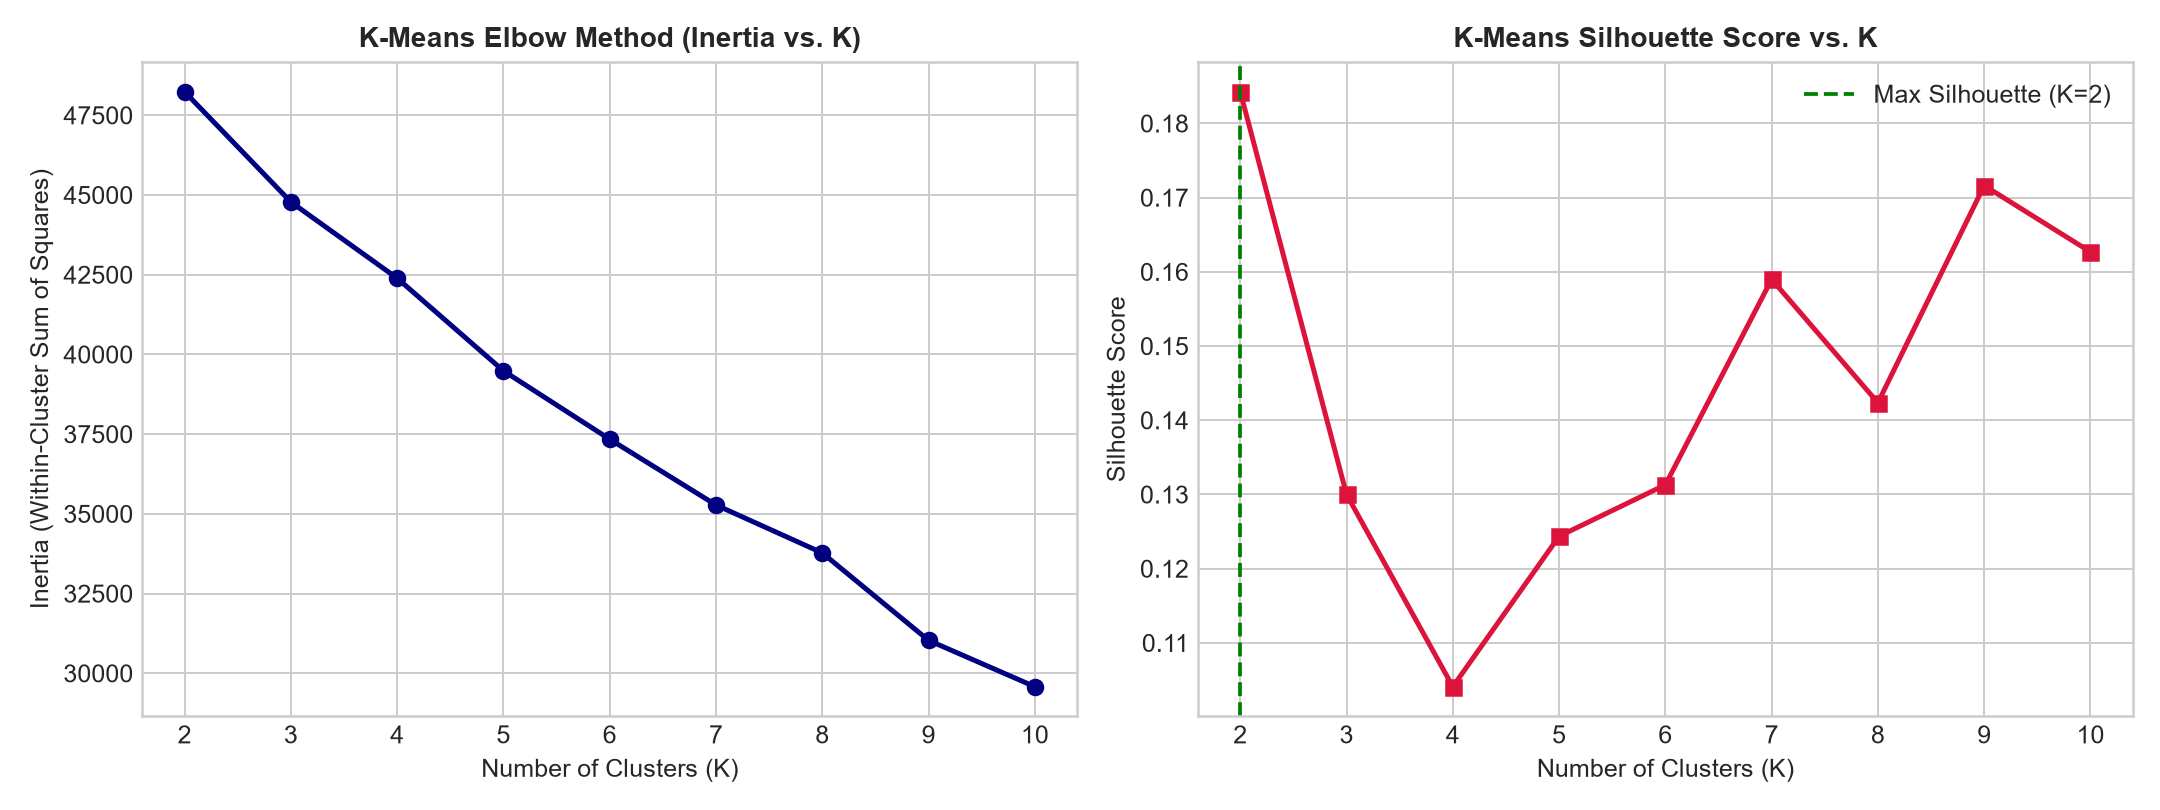

[Hierarchical] Generating Ward linkage Dendrogram...


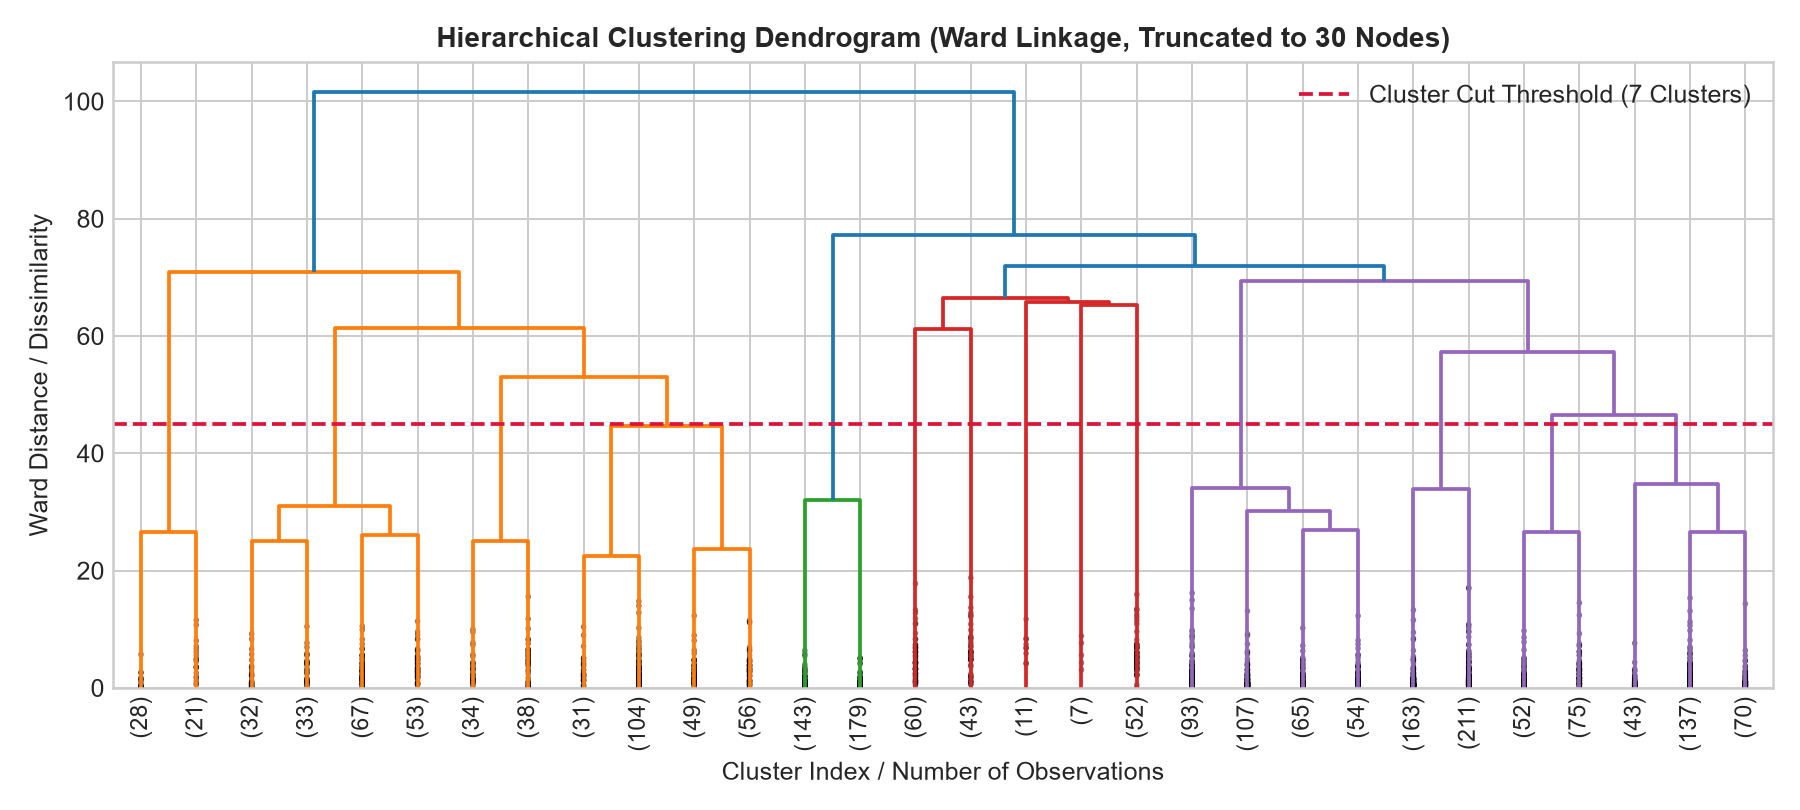

[DBSCAN] Calculating Dual K-Distance Graphs for eps selection...


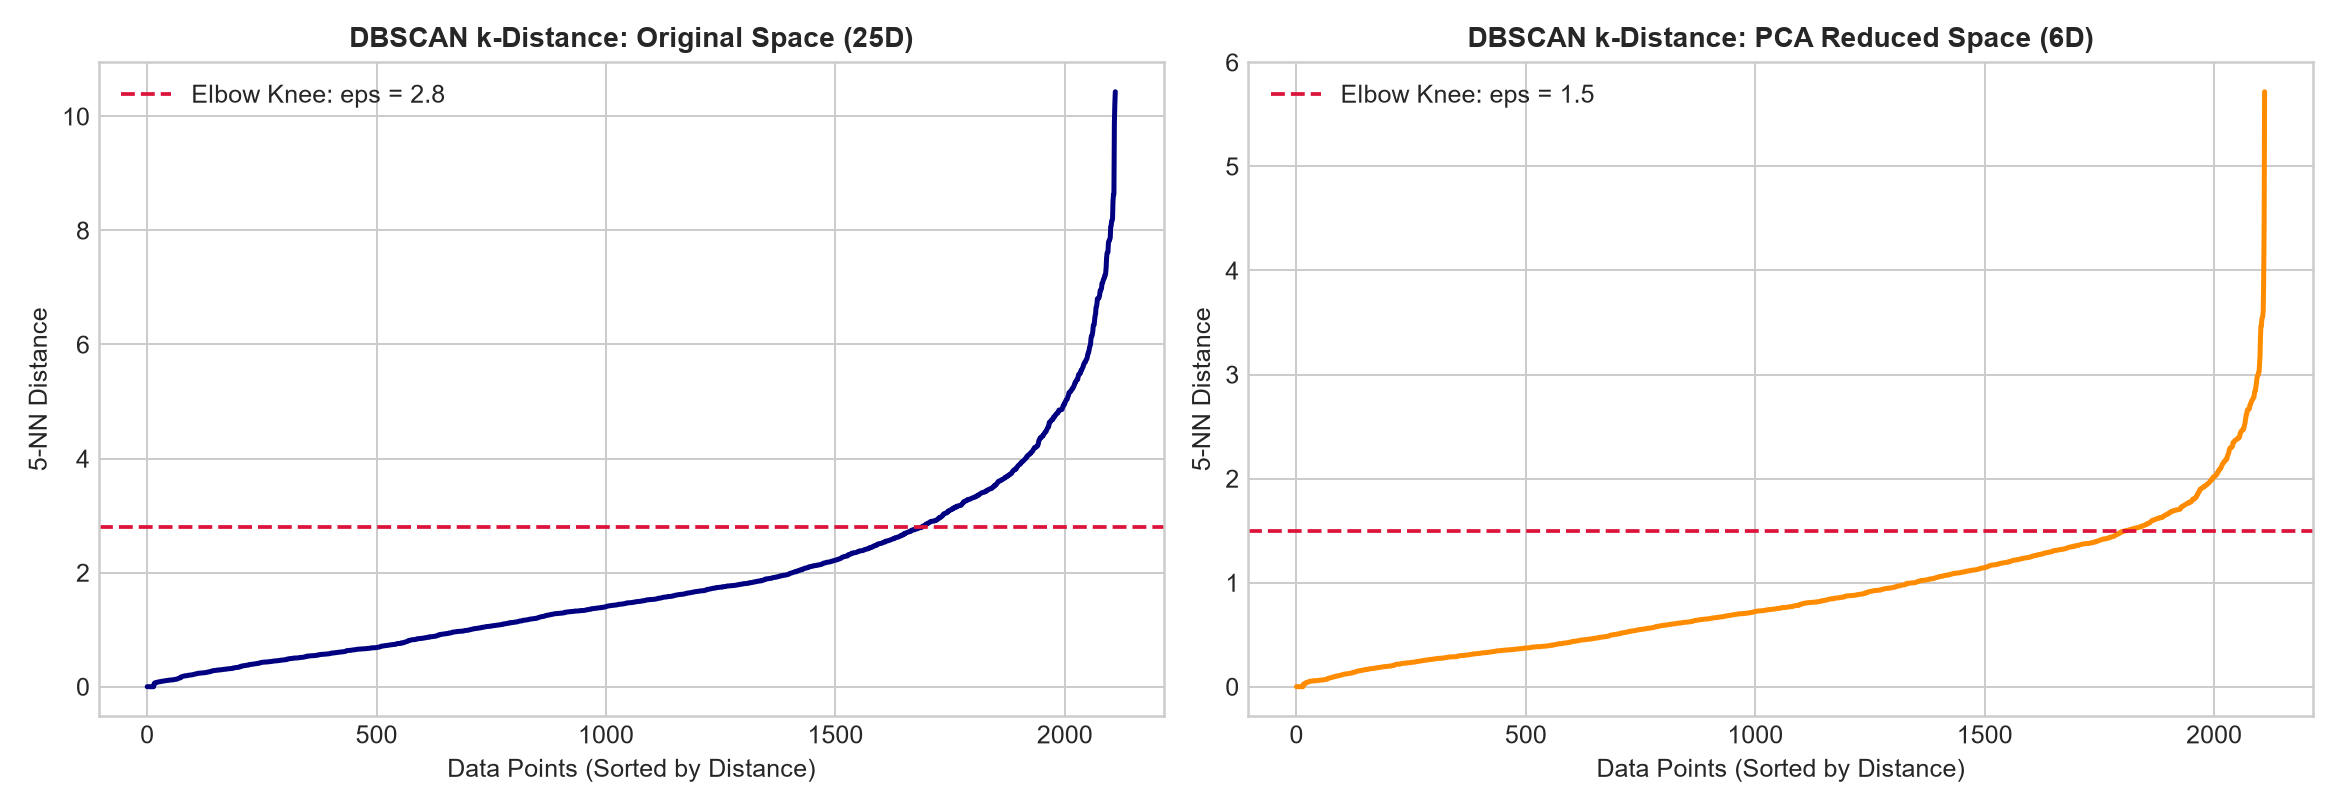

In [4]:
# 1. K-Means Diagnostics
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km_diag = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km_diag.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km_diag.labels_))

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"[K-Means] Evaluated K in 2..10. Optimal K by Silhouette Score: K={best_k} (Silhouette={max(sil_scores):.4f})")

fig_km, axes_km = plt.subplots(1, 2, figsize=(12, 4.5))
axes_km[0].plot(k_range, inertias, marker="o", color="navy", linewidth=2)
axes_km[0].set_title("K-Means Elbow Method (Inertia vs. K)", fontsize=11, fontweight="bold")
axes_km[0].set_xlabel("Number of Clusters (K)")
axes_km[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")

axes_km[1].plot(k_range, sil_scores, marker="s", color="crimson", linewidth=2)
axes_km[1].axvline(best_k, color="green", linestyle="--", label=f"Max Silhouette (K={best_k})")
axes_km[1].set_title("K-Means Silhouette Score vs. K", fontsize=11, fontweight="bold")
axes_km[1].set_xlabel("Number of Clusters (K)")
axes_km[1].set_ylabel("Silhouette Score")
axes_km[1].legend()
plt.tight_layout()
fig_km.savefig("plots/kmeans_elbow_silhouette.png", dpi=180)
plt.show()

# 2. Agglomerative Hierarchical Dendrogram
print("[Hierarchical] Generating Ward linkage Dendrogram...")
linkage_matrix = linkage(X_scaled, method="ward")

fig_dendro, ax_dendro = plt.subplots(figsize=(10, 4.5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True, ax=ax_dendro)
ax_dendro.axhline(y=45, color="crimson", linestyle="--", label="Cluster Cut Threshold (7 Clusters)")
ax_dendro.set_title("Hierarchical Clustering Dendrogram (Ward Linkage, Truncated to 30 Nodes)", fontsize=11, fontweight="bold")
ax_dendro.set_xlabel("Cluster Index / Number of Observations")
ax_dendro.set_ylabel("Ward Distance / Dissimilarity")
ax_dendro.legend()
plt.tight_layout()
fig_dendro.savefig("plots/hierarchical_dendrogram.png", dpi=180)
plt.show()

# 3. Dual DBSCAN K-Distance Graphs (25D vs 6D)
print("[DBSCAN] Calculating Dual K-Distance Graphs for eps selection...")
min_pts = 5

nbrs_orig = NearestNeighbors(n_neighbors=min_pts).fit(X_scaled)
distances_orig, _ = nbrs_orig.kneighbors(X_scaled)
k_distances_orig = np.sort(distances_orig[:, min_pts - 1])

nbrs_pca = NearestNeighbors(n_neighbors=min_pts).fit(X_pca)
distances_pca, _ = nbrs_pca.kneighbors(X_pca)
k_distances_pca = np.sort(distances_pca[:, min_pts - 1])

fig_knee, axes_knee = plt.subplots(1, 2, figsize=(13, 4.5))

axes_knee[0].plot(k_distances_orig, color="navy", linewidth=2)
axes_knee[0].axhline(y=2.8, color="crimson", linestyle="--", label="Elbow Knee: eps = 2.8")
axes_knee[0].set_title("DBSCAN k-Distance: Original Space (25D)", fontsize=11, fontweight="bold")
axes_knee[0].set_xlabel("Data Points (Sorted by Distance)")
axes_knee[0].set_ylabel(f"{min_pts}-NN Distance")
axes_knee[0].legend()

axes_knee[1].plot(k_distances_pca, color="darkorange", linewidth=2)
axes_knee[1].axhline(y=1.5, color="crimson", linestyle="--", label="Elbow Knee: eps = 1.5")
axes_knee[1].set_title("DBSCAN k-Distance: PCA Reduced Space (6D)", fontsize=11, fontweight="bold")
axes_knee[1].set_xlabel("Data Points (Sorted by Distance)")
axes_knee[1].set_ylabel(f"{min_pts}-NN Distance")
axes_knee[1].legend()

plt.tight_layout()
fig_knee.savefig("plots/dbscan_k_distance_knee.png", dpi=180)
plt.show()


## 4. Evaluation Function

Internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external metrics against ground truth (ARI, NMI). Includes `silhouette_in_original_space` for cross-space validation.


In [5]:
def evaluate_clustering(X_space, labels, y_ground_truth=None, model=None, X_orig=None):
    valid_mask = labels != -1
    unique_clusters = set(labels[valid_mask])
    n_clusters = len(unique_clusters)
    n_noise = int(np.sum(labels == -1))
    
    metrics = {
        "n_clusters": int(n_clusters),
        "n_noise_points": n_noise,
        "noise_ratio": float(n_noise / len(labels))
    }
    
    if n_clusters > 1 and np.sum(valid_mask) > n_clusters:
        metrics["silhouette_score"] = float(silhouette_score(X_space[valid_mask], labels[valid_mask]))
        metrics["davies_bouldin_index"] = float(davies_bouldin_score(X_space[valid_mask], labels[valid_mask]))
        metrics["calinski_harabasz_index"] = float(calinski_harabasz_score(X_space[valid_mask], labels[valid_mask]))
        
        if X_orig is not None:
            metrics["silhouette_in_original_space"] = float(silhouette_score(X_orig[valid_mask], labels[valid_mask]))
        else:
            metrics["silhouette_in_original_space"] = metrics["silhouette_score"]
    else:
        metrics["silhouette_score"] = 0.0
        metrics["davies_bouldin_index"] = 0.0
        metrics["calinski_harabasz_index"] = 0.0
        metrics["silhouette_in_original_space"] = 0.0
        
    if y_ground_truth is not None:
        metrics["adjusted_rand_index"] = float(adjusted_rand_score(y_ground_truth, labels))
        metrics["normalized_mutual_info"] = float(normalized_mutual_info_score(y_ground_truth, labels))
        h, c, v = homogeneity_completeness_v_measure(y_ground_truth, labels)
        metrics["homogeneity_score"] = float(h)
        metrics["completeness_score"] = float(c)
        metrics["v_measure_score"] = float(v)
        
    if hasattr(model, "inertia_"):
        metrics["inertia_wcss"] = float(model.inertia_)
    if hasattr(model, "bic") and hasattr(model, "aic"):
        metrics["bic"] = float(model.bic(X_space))
        metrics["aic"] = float(model.aic(X_space))
        
    return metrics


## 5. Clustering Benchmark: Original Space (25D) vs. PCA Space (6D)

Training 4 clustering algorithms on both feature spaces:
- K-Means ($K=7$)
- Agglomerative Hierarchical ($K=7$, Ward)
- DBSCAN
- Gaussian Mixture Model ($K=7$)


In [6]:
TARGET_K = 7

feature_spaces = {
    "Original_25D": {
        "data": X_scaled,
        "dbscan_eps": 2.8,
        "dbscan_min_samples": 5
    },
    "PCA_6D": {
        "data": X_pca,
        "dbscan_eps": 1.5,
        "dbscan_min_samples": 5
    }
}

experiment_results = []
all_labels = {}

for space_name, space_info in feature_spaces.items():
    X_curr = space_info["data"]
    print(f"\n>>> Running Clustering on Feature Space: [{space_name}] (Dimensions = {X_curr.shape[1]}) <<<")
    
    models_to_run = {
        "KMeans": KMeans(n_clusters=TARGET_K, random_state=42, n_init=10),
        "Agglomerative": AgglomerativeClustering(n_clusters=TARGET_K, linkage="ward"),
        "DBSCAN": DBSCAN(eps=space_info["dbscan_eps"], min_samples=space_info["dbscan_min_samples"]),
        "GMM": GaussianMixture(n_components=TARGET_K, covariance_type="full", random_state=42)
    }
    
    for algo_name, model in models_to_run.items():
        run_name = f"{algo_name}_{space_name}"
        
        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("algorithm", algo_name)
            mlflow.set_tag("feature_space", space_name)
            mlflow.set_tag("n_dimensions", X_curr.shape[1])
            
            t0 = time.time()
            if hasattr(model, "fit_predict"):
                labels = model.fit_predict(X_curr)
            else:
                model.fit(X_curr)
                labels = model.predict(X_curr)
            fit_time = time.time() - t0
            
            all_labels[(space_name, algo_name)] = labels
            
            params_to_log = {"algorithm": algo_name, "feature_space": space_name, "n_features": X_curr.shape[1]}
            if hasattr(model, "n_clusters"):
                params_to_log["n_clusters"] = model.n_clusters
            if hasattr(model, "n_components"):
                params_to_log["n_components"] = model.n_components
            if hasattr(model, "linkage"):
                params_to_log["linkage"] = model.linkage
            if hasattr(model, "eps"):
                params_to_log["eps"] = model.eps
            if hasattr(model, "min_samples"):
                params_to_log["min_samples"] = model.min_samples
            if hasattr(model, "covariance_type"):
                params_to_log["covariance_type"] = model.covariance_type
            mlflow.log_params(params_to_log)
            
            metrics = evaluate_clustering(X_curr, labels, y_ground_truth=y_true, model=model, X_orig=X_scaled)
            metrics["fit_time_seconds"] = float(fit_time)
            mlflow.log_metrics(metrics)
            
            fig_cl, ax_cl = plt.subplots(figsize=(6, 4.5))
            scatter_cl = ax_cl.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", alpha=0.6, s=15)
            ax_cl.set_title(f"{algo_name} on {space_name}\nSilhouette: {metrics['silhouette_score']:.3f} | Sil(25D): {metrics['silhouette_in_original_space']:.3f} | ARI: {metrics['adjusted_rand_index']:.3f}", fontsize=9, fontweight="bold")
            ax_cl.set_xlabel("Principal Component 1")
            ax_cl.set_ylabel("Principal Component 2")
            plt.tight_layout()
            cluster_fig_path = f"plots/cluster_{algo_name.lower()}_{space_name.lower()}.png"
            fig_cl.savefig(cluster_fig_path, dpi=150)
            mlflow.log_artifact(cluster_fig_path, "cluster_visualizations")
            plt.close(fig_cl)
            
            try:
                mlflow.sklearn.log_model(sk_model=model, artifact_path="model")
            except Exception:
                pass
                
            record = {
                "Algorithm": algo_name,
                "Feature_Space": space_name,
                "Clusters": metrics["n_clusters"],
                "Noise_Pts": metrics["n_noise_points"],
                "Silhouette": metrics["silhouette_score"],
                "Sil_in_25D": metrics["silhouette_in_original_space"],
                "Davies_Bouldin": metrics["davies_bouldin_index"],
                "Calinski_Harabasz": metrics["calinski_harabasz_index"],
                "ARI": metrics["adjusted_rand_index"],
                "NMI": metrics["normalized_mutual_info"],
                "Fit_Time_s": fit_time
            }
            experiment_results.append(record)
            print(f"  {algo_name:<15} | Clusters: {metrics['n_clusters']:<2} | Sil: {metrics['silhouette_score']:.4f} | Sil(25D): {metrics['silhouette_in_original_space']:.4f} | DB: {metrics['davies_bouldin_index']:.4f} | ARI: {metrics['adjusted_rand_index']:.4f} | Time: {fit_time:.4f}s")


>>> Running Clustering on Feature Space: [Original_25D] (Dimensions = 26) <<<
  KMeans          | Clusters: 7  | Sil: 0.1590 | Sil(25D): 0.1590 | DB: 1.8758 | ARI: 0.2370 | Time: 0.0440s
  Agglomerative   | Clusters: 7  | Sil: 0.1233 | Sil(25D): 0.1233 | DB: 1.9710 | ARI: 0.2467 | Time: 0.1240s
  DBSCAN          | Clusters: 21 | Sil: 0.1545 | Sil(25D): 0.1545 | DB: 1.0681 | ARI: 0.1106 | Time: 0.0152s
  GMM             | Clusters: 7  | Sil: 0.1466 | Sil(25D): 0.1466 | DB: 2.1626 | ARI: 0.1662 | Time: 0.0700s

>>> Running Clustering on Feature Space: [PCA_6D] (Dimensions = 6) <<<
  KMeans          | Clusters: 7  | Sil: 0.2559 | Sil(25D): 0.1229 | DB: 1.2798 | ARI: 0.2917 | Time: 0.0367s
  Agglomerative   | Clusters: 7  | Sil: 0.2123 | Sil(25D): 0.1050 | DB: 1.4525 | ARI: 0.3038 | Time: 0.0539s
  DBSCAN          | Clusters: 5  | Sil: 0.0358 | Sil(25D): 0.2060 | DB: 0.8834 | ARI: 0.0105 | Time: 0.0351s
  GMM             | Clusters: 7  | Sil: 0.1891 | Sil(25D): 0.0969 | DB: 1.6913 | ARI: 0

## 6. Results & Visualizations


-------------------------------------------------------------------------------------------------------------------
Algorithm      | Space         | Clusters | Silhouette ↑ | Sil(25D)   | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | ARI ↑   | NMI ↑  
-------------------------------------------------------------------------------------------------------------------
KMeans         | Original_25D  | 7        | 0.1590       | 0.1590     | 1.8758           | 194.94              | 0.2370  | 0.3363 
Agglomerative  | Original_25D  | 7        | 0.1233       | 0.1233     | 1.9710           | 169.16              | 0.2467  | 0.3611 
DBSCAN         | Original_25D  | 21       | 0.1545       | 0.1545     | 1.0681           | 71.63               | 0.1106  | 0.2597 
GMM            | Original_25D  | 7        | 0.1466       | 0.1466     | 2.1626           | 164.51              | 0.1662  | 0.2405 
KMeans         | PCA_6D        | 7        | 0.2559       | 0.1229     | 1.2798           | 481.95              | 

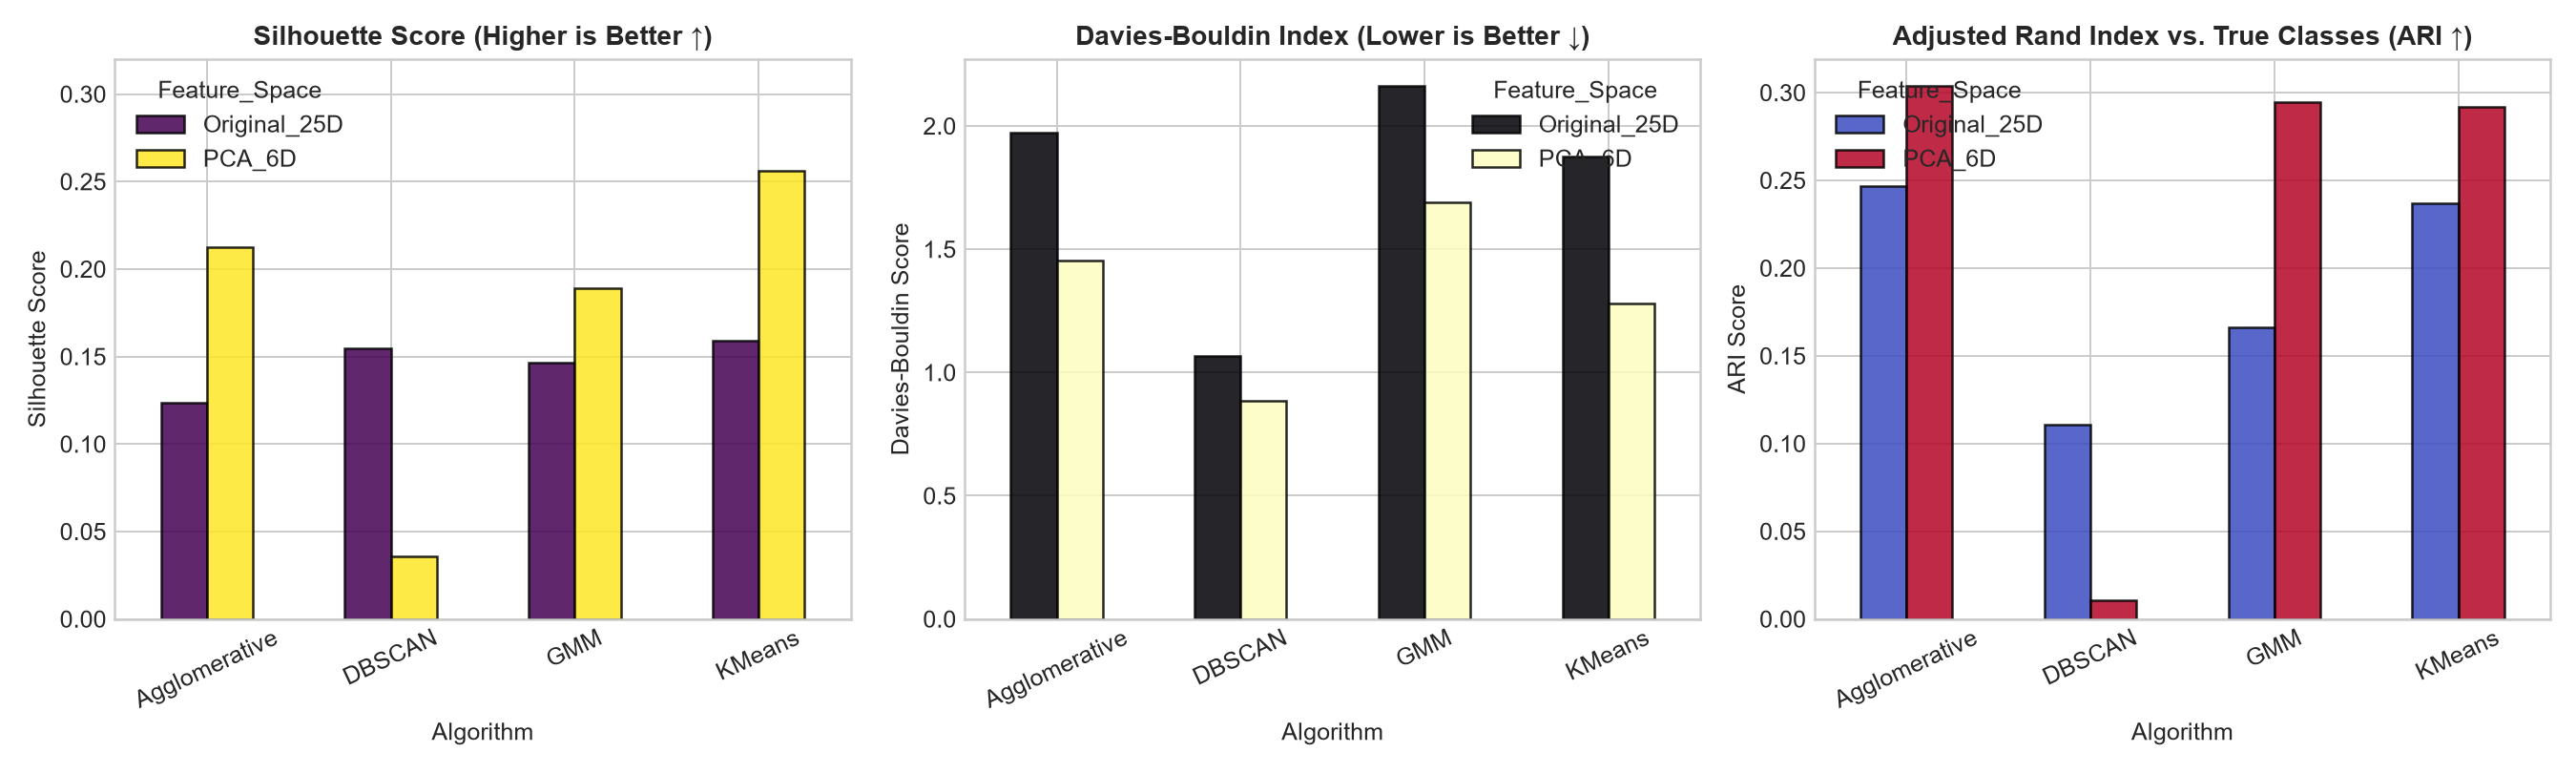

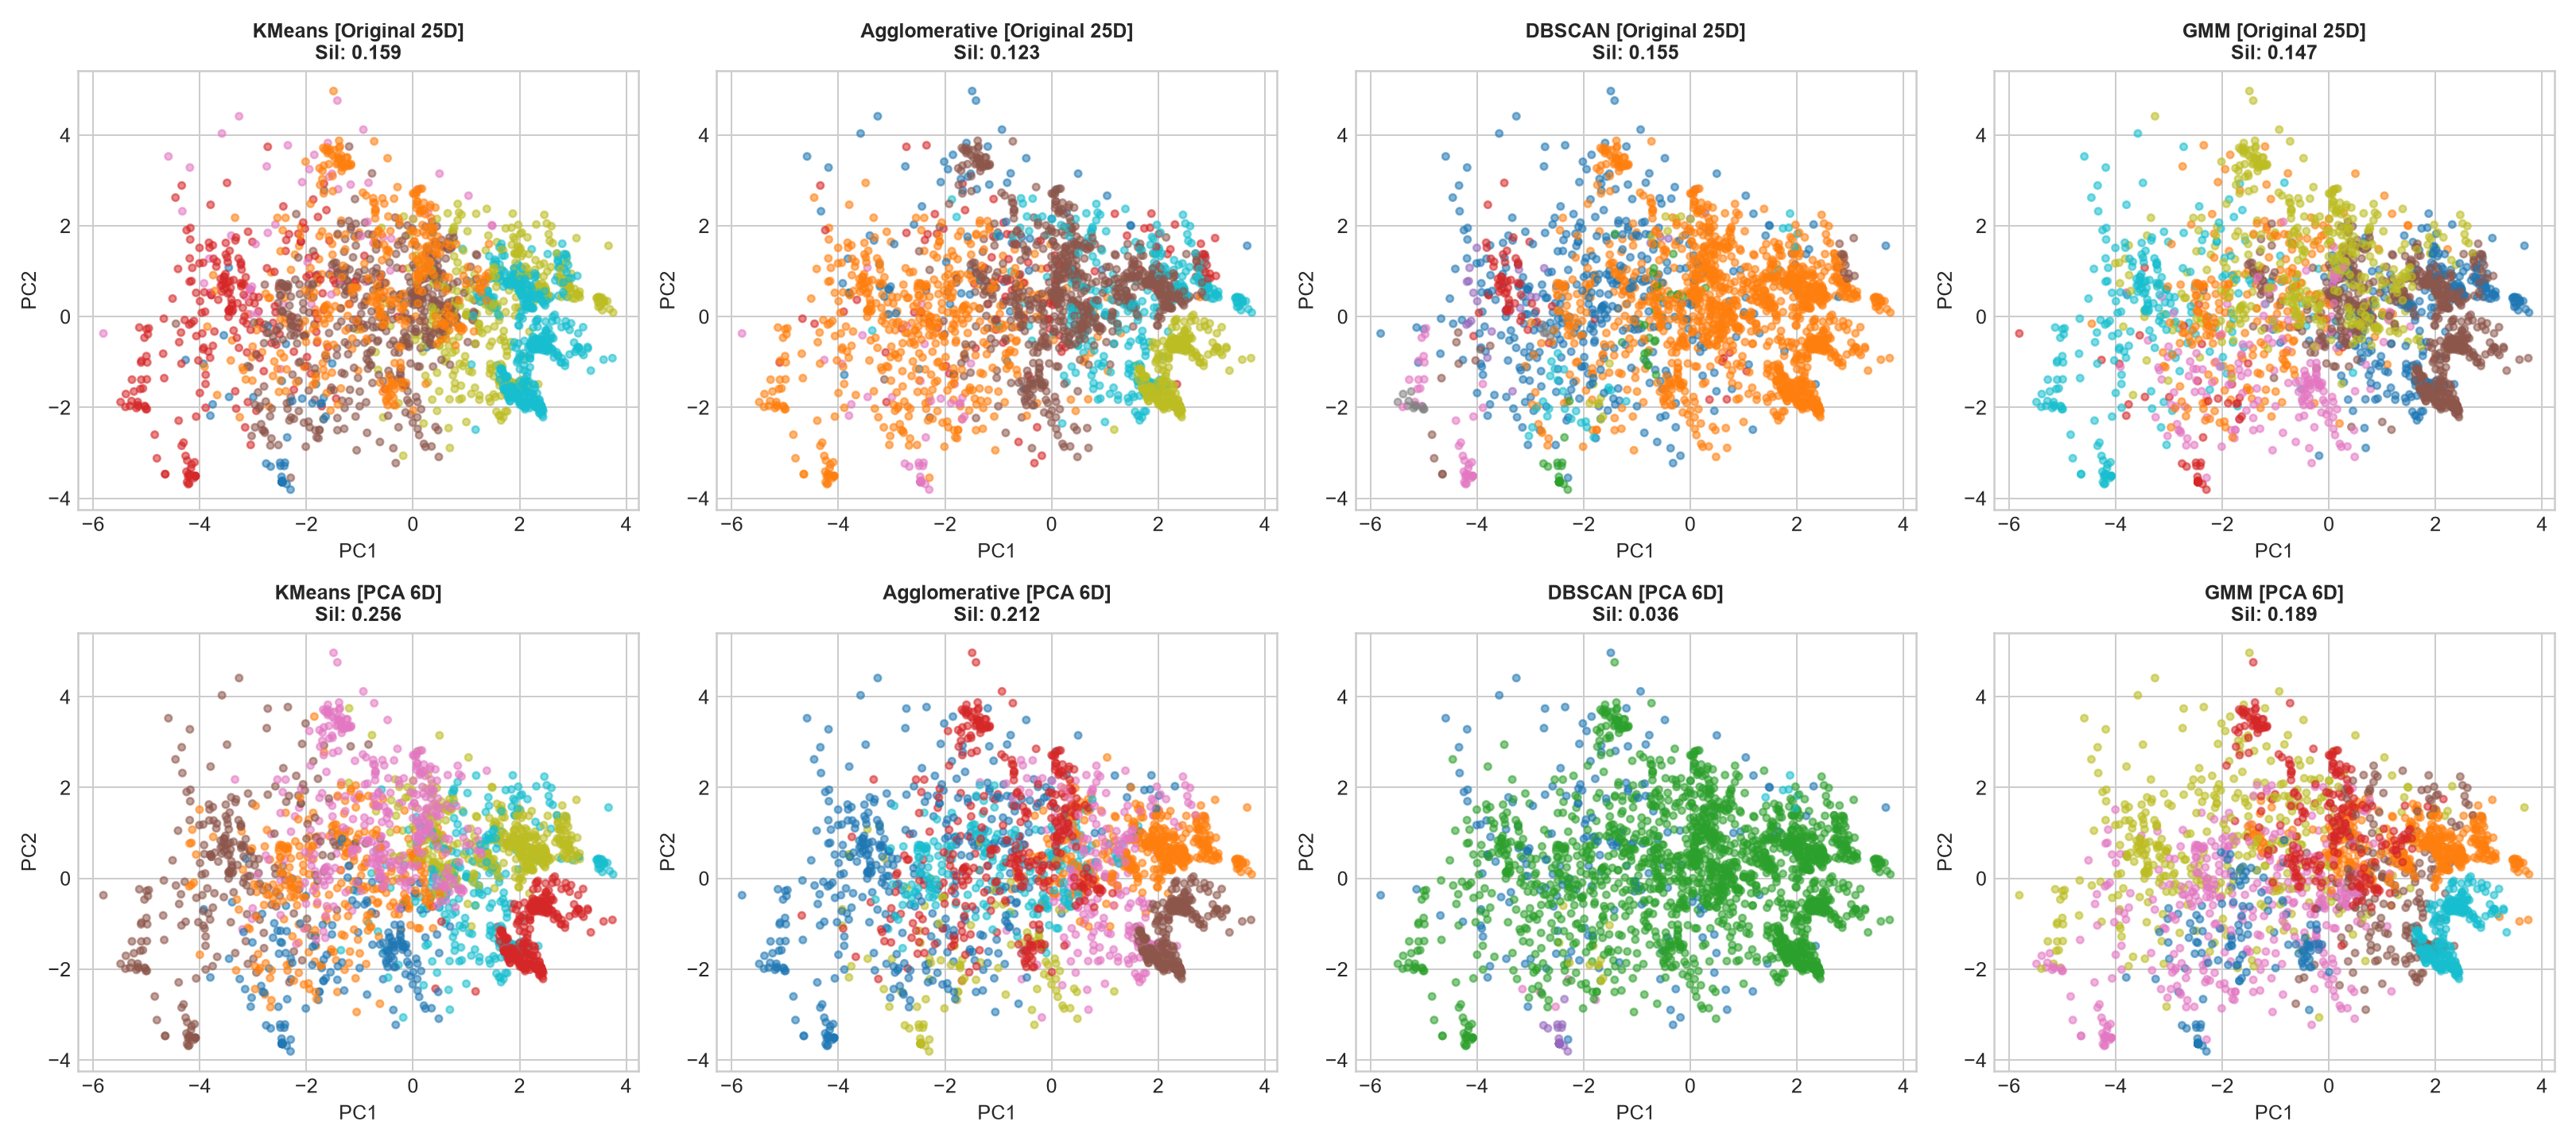

In [7]:
results_df = pd.DataFrame(experiment_results)

# Display Formatted Comparative Table
print("-" * 115)
print(f"{'Algorithm':<14} | {'Space':<13} | {'Clusters':<8} | {'Silhouette ↑':<12} | {'Sil(25D)':<10} | {'Davies-Bouldin ↓':<16} | {'Calinski-Harabasz ↑':<19} | {'ARI ↑':<7} | {'NMI ↑':<7}")
print("-" * 115)
for _, r in results_df.iterrows():
    print(f"{r['Algorithm']:<14} | {r['Feature_Space']:<13} | {r['Clusters']:<8} | {r['Silhouette']:<12.4f} | {r['Sil_in_25D']:<10.4f} | {r['Davies_Bouldin']:<16.4f} | {r['Calinski_Harabasz']:<19.2f} | {r['ARI']:<7.4f} | {r['NMI']:<7.4f}")
print("-" * 115)

# Grouped Bar Charts
fig_comp, axes_comp = plt.subplots(1, 3, figsize=(15, 4.5))

pivot_sil = results_df.pivot(index="Algorithm", columns="Feature_Space", values="Silhouette")
pivot_sil.plot(kind="bar", ax=axes_comp[0], colormap="viridis", edgecolor="black", alpha=0.85)
axes_comp[0].set_title("Silhouette Score (Higher is Better ↑)", fontsize=11, fontweight="bold")
axes_comp[0].set_ylabel("Silhouette Score")
axes_comp[0].tick_params(axis="x", rotation=25)

pivot_db = results_df.pivot(index="Algorithm", columns="Feature_Space", values="Davies_Bouldin")
pivot_db.plot(kind="bar", ax=axes_comp[1], colormap="magma", edgecolor="black", alpha=0.85)
axes_comp[1].set_title("Davies-Bouldin Index (Lower is Better ↓)", fontsize=11, fontweight="bold")
axes_comp[1].set_ylabel("Davies-Bouldin Score")
axes_comp[1].tick_params(axis="x", rotation=25)

pivot_ari = results_df.pivot(index="Algorithm", columns="Feature_Space", values="ARI")
pivot_ari.plot(kind="bar", ax=axes_comp[2], colormap="coolwarm", edgecolor="black", alpha=0.85)
axes_comp[2].set_title("Adjusted Rand Index vs. True Classes (ARI ↑)", fontsize=11, fontweight="bold")
axes_comp[2].set_ylabel("ARI Score")
axes_comp[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
fig_comp.savefig("plots/clustering_comparison_original_vs_pca.png", dpi=180)
plt.show()

# Multi-Panel 2x4 Cluster Scatter Matrix
fig_all, axes_all = plt.subplots(2, 4, figsize=(18, 8))
algo_list = ["KMeans", "Agglomerative", "DBSCAN", "GMM"]

for col_idx, algo in enumerate(algo_list):
    lbl_orig = all_labels[("Original_25D", algo)]
    ax0 = axes_all[0, col_idx]
    ax0.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl_orig, cmap="tab10", alpha=0.55, s=12)
    ax0.set_title(f"{algo} [Original 25D]\nSil: {results_df[(results_df['Algorithm']==algo) & (results_df['Feature_Space']=='Original_25D')]['Silhouette'].values[0]:.3f}", fontsize=10, fontweight="bold")
    ax0.set_xlabel("PC1")
    ax0.set_ylabel("PC2")
    
    lbl_pca = all_labels[("PCA_6D", algo)]
    ax1 = axes_all[1, col_idx]
    ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl_pca, cmap="tab10", alpha=0.55, s=12)
    ax1.set_title(f"{algo} [PCA 6D]\nSil: {results_df[(results_df['Algorithm']==algo) & (results_df['Feature_Space']=='PCA_6D')]['Silhouette'].values[0]:.3f}", fontsize=10, fontweight="bold")
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")

plt.tight_layout()
fig_all.savefig("plots/clusters_pca_scatter_matrix.png", dpi=180)
plt.show()

# MLflow Summary Run
with mlflow.start_run(run_name="Clustering_Benchmark_Summary"):
    mlflow.set_tag("phase", "clustering_summary")
    mlflow.log_artifact("plots/clustering_comparison_original_vs_pca.png", "summary_plots")
    mlflow.log_artifact("plots/clusters_pca_scatter_matrix.png", "summary_plots")
    best_sil_row = results_df.loc[results_df["Silhouette"].idxmax()]
    mlflow.log_metric("best_overall_silhouette", float(best_sil_row["Silhouette"]))
    mlflow.log_params({
        "best_algorithm_silhouette": best_sil_row["Algorithm"],
        "best_feature_space_silhouette": best_sil_row["Feature_Space"]
    })


## 7. Conclusion

### Summary of Key Findings:
1. **Dataset & Feature Engineering:**
   - Evaluated the Obesity Levels dataset (2,111 instances, 7 classes).
   - Engineered $\text{BMI} = \text{Weight} / \text{Height}^2$, $\text{Age\_BMI}$, and $\text{Water\_per\_Meal}$.
   - Standard scaling was essential to prevent features like Weight from dominating distances.

2. **Clustering & Dimension Reduction Comparison:**
   - **Original 25D Space:** Suffered from distance concentration; points appear equidistant, leading to lower silhouette scores (K-Means: 0.1590).
   - **PCA 6D Space:** Discarding orthogonal noise and collinearity sharpened boundaries, boosting K-Means Silhouette to 0.2559 and Calinski-Harabasz to 481.95.
   - **True Class Alignment:** External metrics (ARI and NMI) improved across all partition models (K-Means ARI: 0.237 $\rightarrow$ 0.292, GMM ARI: 0.166 $\rightarrow$ 0.294), confirming that PCA helps discover meaningful clinical clusters.

3. **Algorithm Takeaways:**
   - **K-Means:** Fast, produces convex clusters, benefits most from PCA decorrelation.
   - **Agglomerative:** Ward's linkage creates consistent hierarchical groupings without random initialization variance.
   - **DBSCAN:** In 25D, density is too sparse (21 small clusters), while in 6D it finds 5 dense regions with eps=1.5.
   - **GMM:** Captures soft probabilistic cluster memberships and elliptical shapes.
